In [30]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [31]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNEL = 3
EPOCHS = 5

In [32]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "Potato_dataset",
    shuffle = True, 
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [33]:
# Looking the different classes of data
class_names = dataset.class_names
class_names


['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

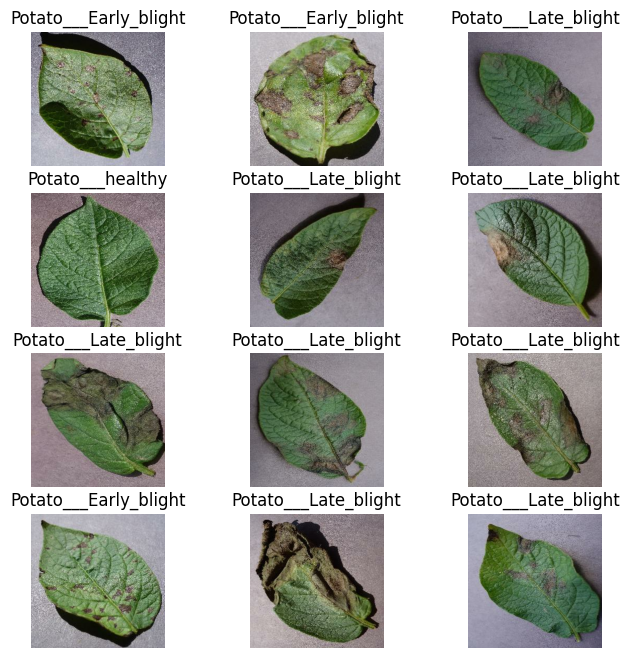

In [34]:
# This cell of code is for representing the images of the batches with their associated labels.
plt.figure(figsize=(8,8))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):    
        ax = plt.subplot(4,3,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis('off')

In [35]:
len(dataset)

68

In [37]:
# Now we will split the dataset into Training, Validation and Testing.
# 80% ==> Training
# 20% ==> 10% validation, 10% test


In [38]:
# For doing rough calcualtion on how much of the dataset can be taken for Training ie. how much is 80% of the dataset
train_size = 0.8
len(dataset) * train_size


54.400000000000006

In [39]:
train_ds = dataset.take(54)

In [40]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [41]:
val_size = 0.1
len(dataset) * val_size

6.800000000000001

In [42]:
val_size = test_ds.take(6)
len(val_size)

6

In [43]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [44]:
def get_dataset_partition_tf(ds, train_split = 0.8, test_split = 0.1, val_split = 0.1, shuffle = True, shuffle_size = 1000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed =12)
        
    train_size = int(ds_size * train_split)
    val_size = int (ds_size * val_split)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds
    

In [51]:
train_ds, val_ds, test_ds = get_dataset_partition_tf(dataset)
print(len(train_ds))
print( len(val_ds))
print(len(test_ds))

54
6
8


In [52]:
# This cell of code is for optimizing the data pipeline where the images are kept in the cache for future use and the batches are prefetched 
# by the cpu while the gpu is still training.

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)



In [60]:
# Now we do preprocessing and  augumentation inorder to increase the numbers of data and variety of data.

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),  # Here we are defining the size for outside images i.e user input.
    layers.Rescaling(1.0/255)
])



In [61]:
 data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])